# Домашнее задание: Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели
## Занятие: Ансамбли моделей
### Версия fix, переделанная в соответсвии с рекомендациями преподавателя.
```
Добрый день!
EDA
Нет явной проверки дубликатов.
Утверждение, что признаки number_of_reviews, reviews_per_month, availability_365
“не несут полезной информации для модели”, слишком сильное:
слабая линейная корреляция с price не означает бесполезность признака.
В EDA нет отдельного анализа категориальных признаков по целевой переменной
до начала feature engineering.

Preprocessing / Feature Engineering
Признаки number_of_reviews, reviews_per_month, availability_365 удалены слишком рано
и только на основании корреляции с целевой переменной.
После логарифмирования minimum_nights и calculated_host_listings_count
признаки удаляются без строгого обоснования; логика “логарифм не помогает, значит удаляем” слишком слабая.
Итерация 4 методически некорректна: локальная обрезка по 95-му перцентилю
делается до train/test split, то есть порог вычисляется с использованием будущего теста.
Это утечка данных.
В итерации 4 одновременно меняются сразу несколько вещей:
локальная обрезка, новый target encoding и poly features.
Из-за этого нельзя понять, что именно дало основной прирост.

Моделирование
Не выведены лучшие гиперпараметры для RidgeCV, LassoCV, ElasticNetCV.
Нет анализа остатков. Нет визуализации y_true vs y_pred.
В выводе про “мультиколлинеарности нет” утверждение слишком категоричное; оно не доказано отдельно.
Финальный вывод по итерации 4 опирается на результат,
полученный с утечкой данных, поэтому делать из него основной вывод о качестве модели нельзя.

С уважением, Василий
```

## Часть 1. EDA

### 1. Загрузка данных

In [1]:
import pandas as pd

In [2]:
# Загружаем датасет
data = pd.read_csv('data/AB_NYC_2019.csv')

# Размерность
print(data.shape)

(48895, 16)


In [3]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
# Удаляем технические признаки
technical_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
data = data.drop(columns=technical_cols)

print(data.shape)
data.head()

(48895, 11)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### 2. Первичная проверка

In [6]:
# Пропуски по каждому столбцу
print('Пропуски по столбцам:')
print(data.isnull().sum())

Пропуски по столбцам:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [7]:
# Полные дубликаты строк
n_duplicates = data.duplicated().sum()
print(f'Полных дубликатов строк: {n_duplicates}')

if n_duplicates > 0:
    data = data.drop_duplicates()
    print(f'Удалено строк: {n_duplicates}. Новый размер: {data.shape}')
else:
    print('Дубликатов нет, удаление не требуется.')

Полных дубликатов строк: 0
Дубликатов нет, удаление не требуется.


In [8]:
# Типы признаков
print('Типы признаков:')
print(data.dtypes)

Типы признаков:
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [9]:
# Разделение признаков на числовые и категориальные
num_cols = data.select_dtypes(include='number').columns.tolist()
cat_cols = data.select_dtypes(include='str').columns.tolist()

print(f'Числовые признаки ({len(num_cols)}): {num_cols}')
print(f'Категориальные признаки ({len(cat_cols)}): {cat_cols}')

Числовые признаки (8): ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Категориальные признаки (3): ['neighbourhood_group', 'neighbourhood', 'room_type']


### 3. Анализ целевой переменной `price`

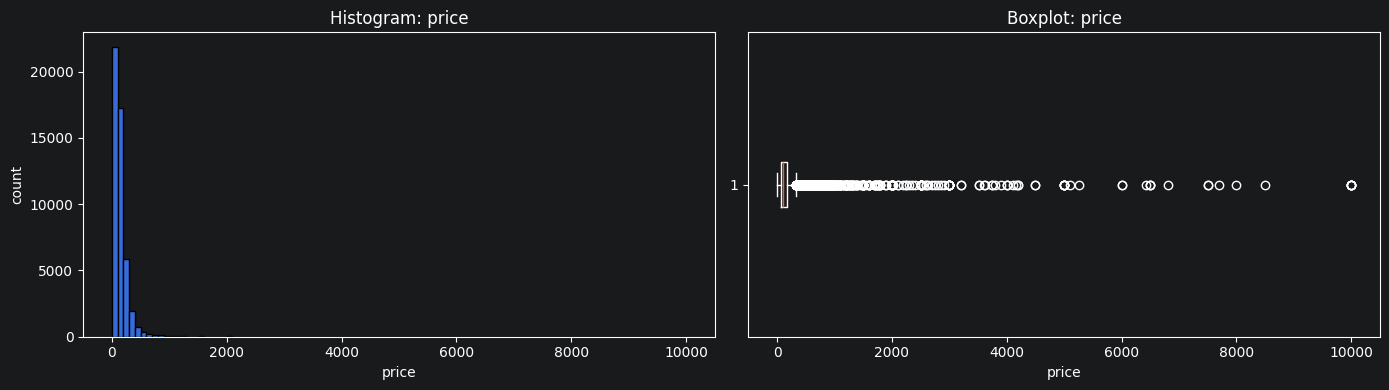

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(data['price'], bins=100, edgecolor='black')
axes[0].set_title('Histogram: price')
axes[0].set_xlabel('price')
axes[0].set_ylabel('count')

# Boxplot
axes[1].boxplot(data['price'], vert=False)
axes[1].set_title('Boxplot: price')
axes[1].set_xlabel('price')

plt.tight_layout()
plt.show()

In [11]:
# Основные статистики
stats = data['price'].agg(['mean', 'median', 'std', 'min', 'max'])
quantiles = data['price'].quantile([0.25, 0.75, 0.90, 0.95, 0.99])

print('Основные статистики:')
print(stats)
print()
print('Квантили:')
print(quantiles)


Основные статистики:
mean        152.720687
median      106.000000
std         240.154170
min           0.000000
max       10000.000000
Name: price, dtype: float64

Квантили:
0.25     69.0
0.75    175.0
0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64


In [12]:
# Проверка асимметрии и выбросов
# Skewness (коэффициент асимметрии) мера того, насколько распределение отклоняется от симметричного.
#
#   skewness = 0       симметричное распределение (как нормальное)
#   skewness > 0       правый хвост длиннее (правая асимметрия)
#   skewness < 0       левый хвост длиннее (левая асимметрия)
#
#   Практические пороги:
#   |skewness| < 0.5   примерно симметричное
#   |skewness| 0.5–1   умеренная асимметрия
#   |skewness| > 1     сильная асимметрия
#
# IQR (Interquartile Range) межквартильный размах.
#
# Это разность между 75-м и 25-м перцентилями:
#
# IQR = Q3 - Q1
# Показывает, в каком диапазоне находится средние 50% данных. Используется для определения выбросов по правилу:
#
# выброс < Q1 - 1.5 * IQR
# выброс > Q3 + 1.5 * IQR
#
# Для price:
# Q1 ~ 69 (25% объявлений дешевле этой цены)
# Q3 ~ 175 (75% объявлений дешевле этой цены)
# IQR ~ 106
# Верхняя граница ~ 175 + 1.5×106 = 334 всё дороже считается выбросом по этому правилу

skewness = data['price'].skew()
iqr = data['price'].quantile(0.75) - data['price'].quantile(0.25)
lower_fence = data['price'].quantile(0.25) - 1.5 * iqr
upper_fence = data['price'].quantile(0.75) + 1.5 * iqr
n_outliers = ((data['price'] < lower_fence) | (data['price'] > upper_fence)).sum()

print(f'Коэффициент асимметрии (skewness): {skewness:.2f}')
print(f'IQR: {iqr:.2f}  |  Нижняя граница IQR: {lower_fence:.2f}  |  Верхняя граница IQR: {upper_fence:.2f}')
print(f'Выбросов по правилу 1.5*IQR: {n_outliers} ({n_outliers / len(data) * 100:.1f}%)')

Коэффициент асимметрии (skewness): 19.12
IQR: 106.00  |  Нижняя граница IQR: -90.00  |  Верхняя граница IQR: 334.00
Выбросов по правилу 1.5*IQR: 2972 (6.1%)


**Выводы:**
- Распределение `price` несимметрично: выражена сильная правая асимметрия (skewness > 1).
- Присутствует длинный правый хвост, есть объекты с ценой в тысячи долларов за ночь.
- Выбросов по правилу 1.5×IQR значительное количество, они сосредоточены в правом хвосте.
- Логарифмирование `price` имеет смысл, оно может сделать распределение ближе к нормальному и улучшить качество модели.

### 4. Анализ числовых признаков


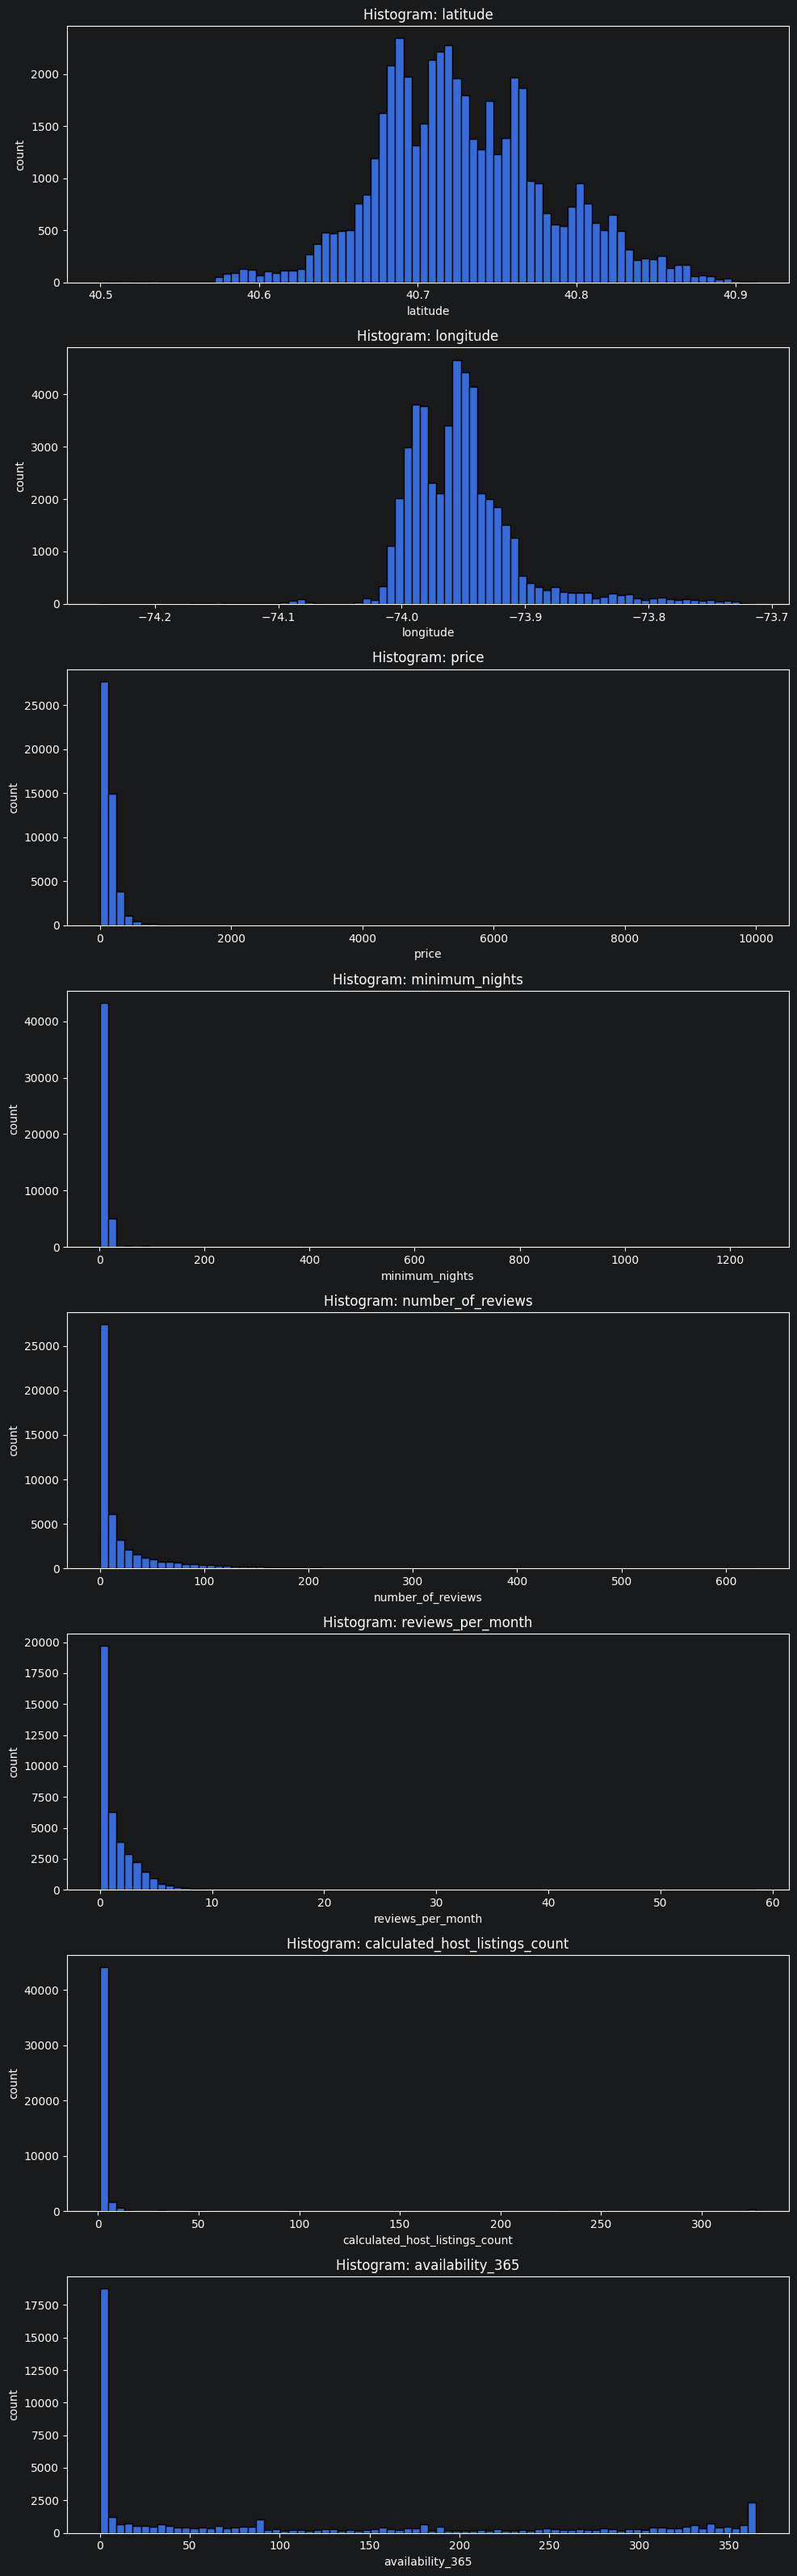

In [13]:
# Histogram для каждого числового признака
# num_cols включает price, показываем все числовые признаки
n = len(num_cols)
fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))

for i, col in enumerate(num_cols):
    axes[i].hist(data[col].dropna(), bins=80, edgecolor='black')
    axes[i].set_title(f'Histogram: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.tight_layout()
plt.show()

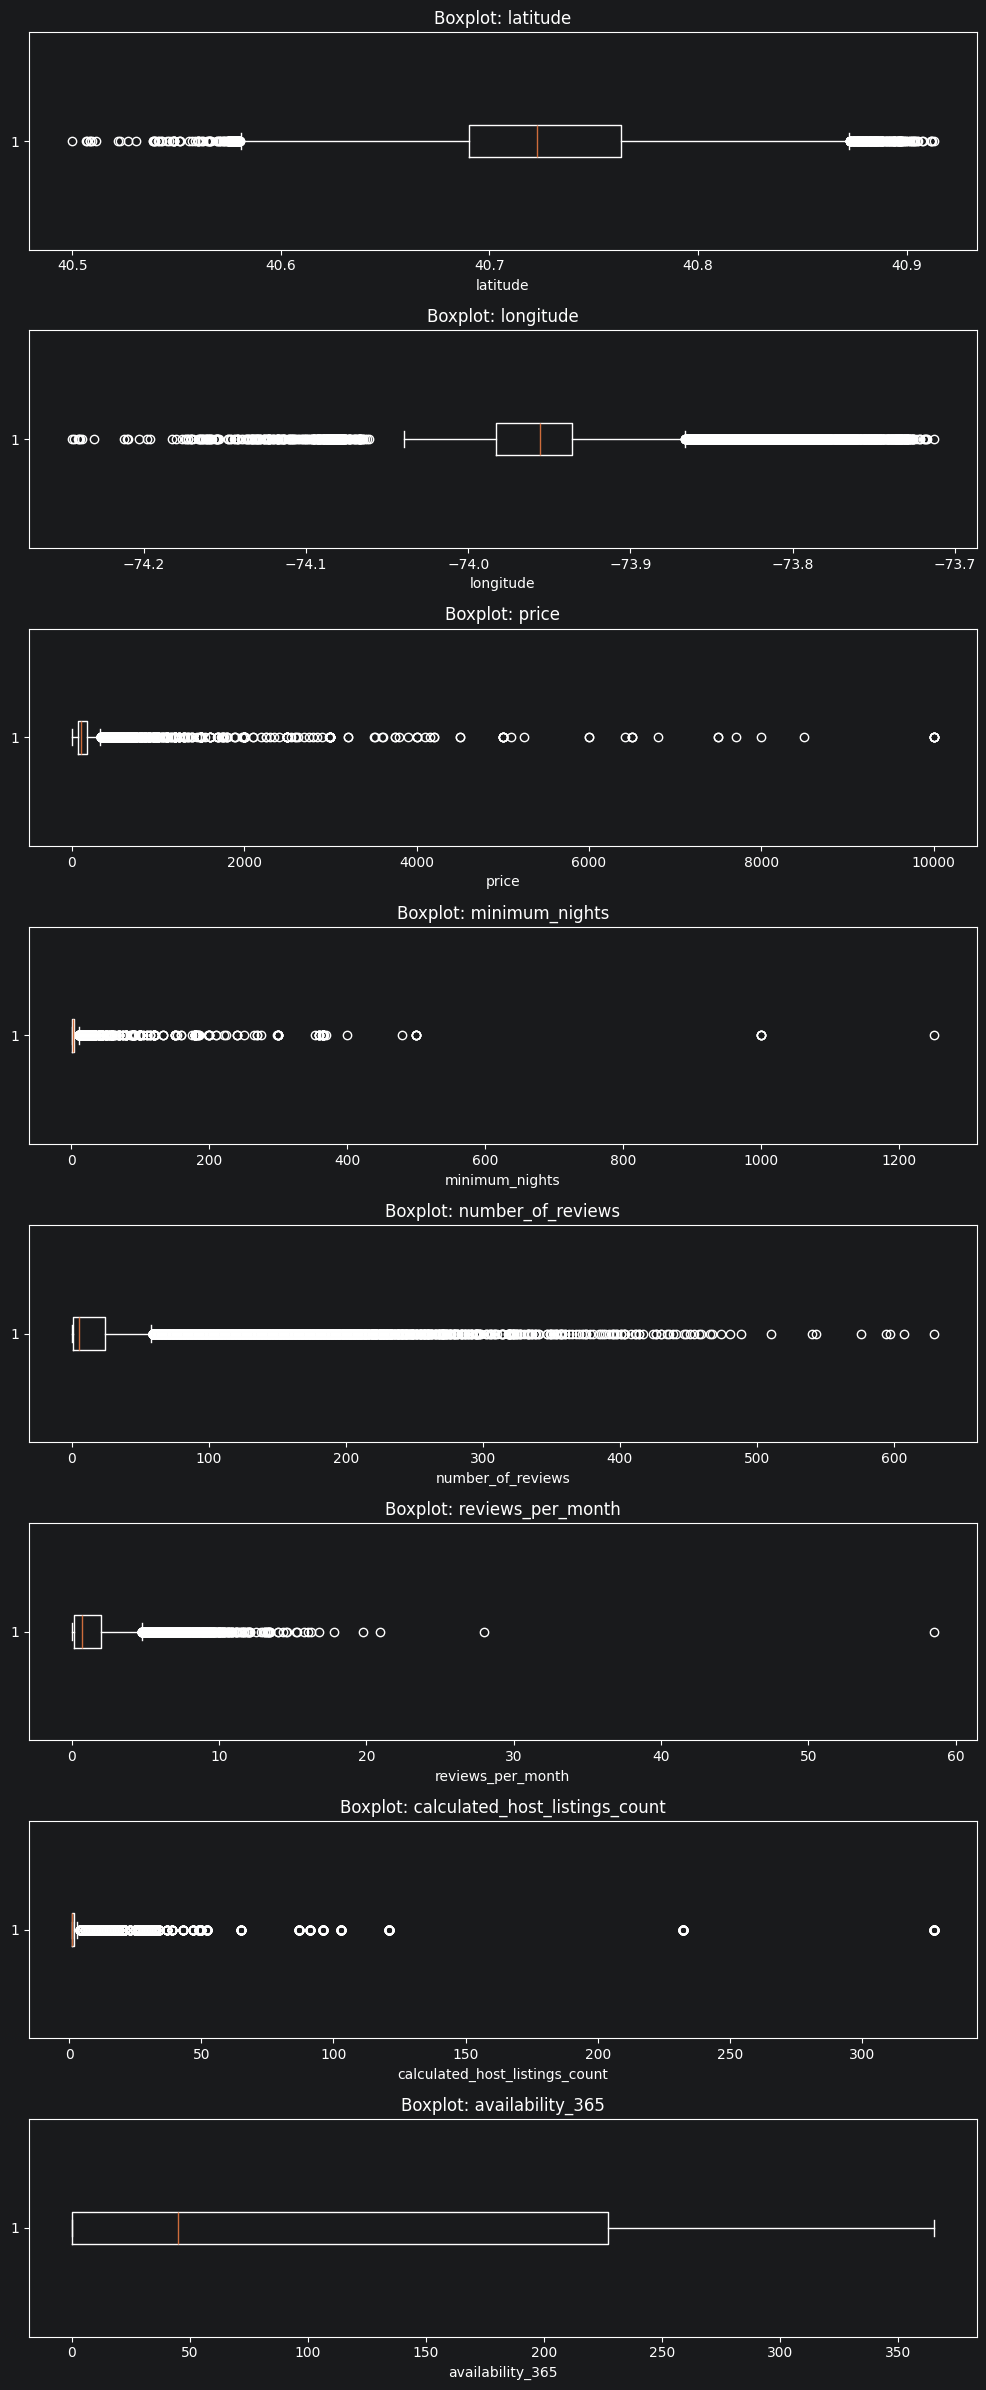

In [14]:
# Boxplot для каждого числового признака
fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))

for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col].dropna(), vert=False)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# Корреляционная матрица числовых признаков
corr_matrix = data[num_cols].corr()
print('Корреляционная матрица:')
print(corr_matrix.round(2))

Корреляционная матрица:
                                latitude  longitude  price  minimum_nights  \
latitude                            1.00       0.08   0.03            0.02   
longitude                           0.08       1.00  -0.15           -0.06   
price                               0.03      -0.15   1.00            0.04   
minimum_nights                      0.02      -0.06   0.04            1.00   
number_of_reviews                  -0.02       0.06  -0.05           -0.08   
reviews_per_month                  -0.01       0.15  -0.03           -0.12   
calculated_host_listings_count      0.02      -0.11   0.06            0.13   
availability_365                   -0.01       0.08   0.08            0.14   

                                number_of_reviews  reviews_per_month  \
latitude                                    -0.02              -0.01   
longitude                                    0.06               0.15   
price                                       -0.05        

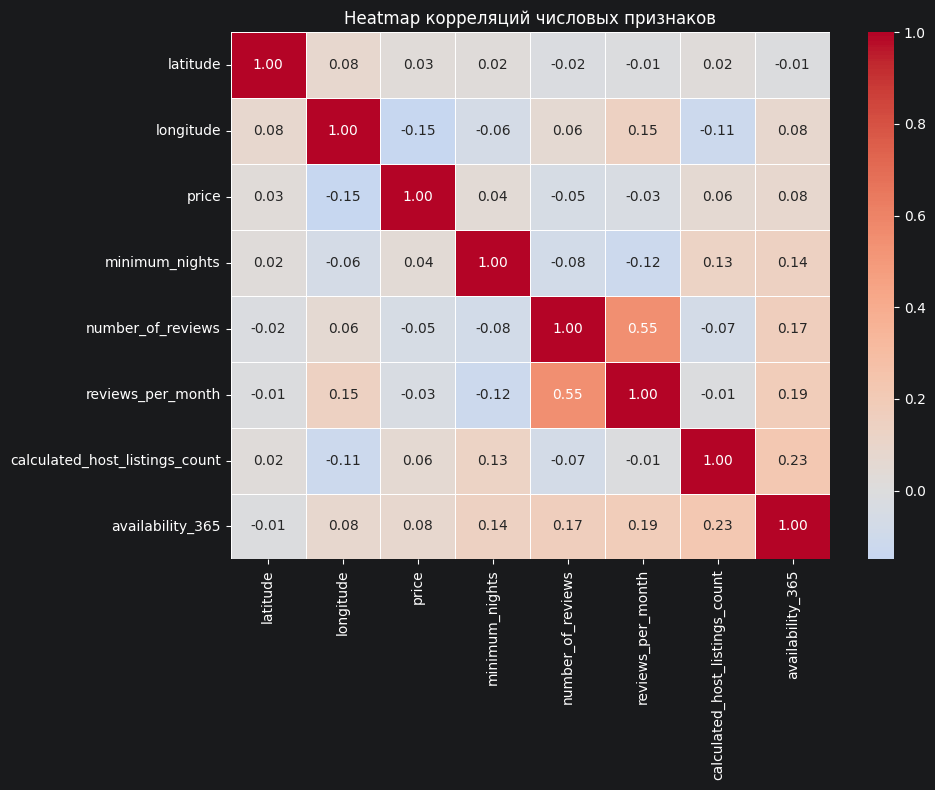

In [16]:
import seaborn as sns

# Heatmap корреляций
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Heatmap корреляций числовых признаков')
plt.tight_layout()
plt.show()

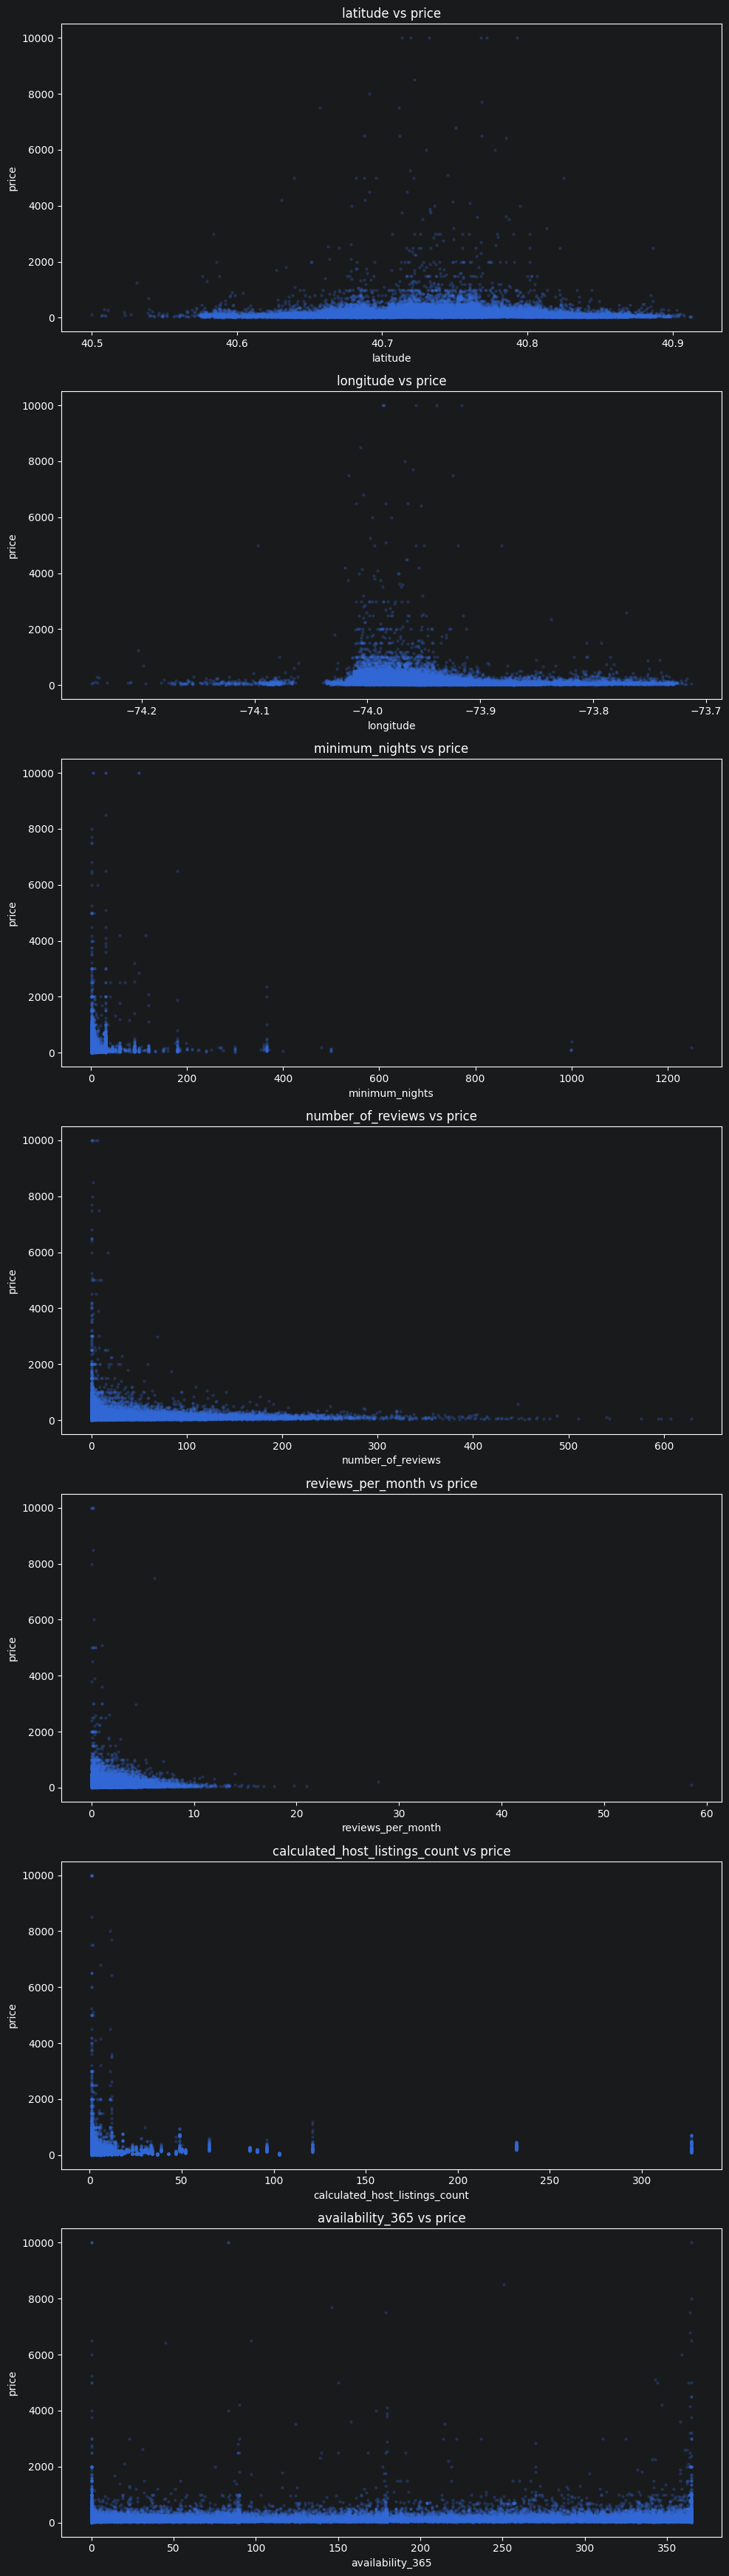

In [17]:
# Scatterplot: связь числовых признаков с price
# Берём признаки кроме самого price
scatter_cols = [col for col in num_cols if col != 'price']

fig, axes = plt.subplots(len(scatter_cols), 1, figsize=(10, 5 * len(scatter_cols)))

for i, col in enumerate(scatter_cols):
    axes[i].scatter(data[col], data['price'], alpha=0.2, s=5)
    axes[i].set_title(f'{col} vs price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')

plt.tight_layout()
plt.show()

**Выводы:**
- Большинство числовых признаков имеют правостороннюю асимметрию с выбросами.
- Корреляции числовых признаков с `price` слабые по модулю, линейная связь не выражена, что ожидаемо для ценовых данных с выбросами.
- На scatterplot с `log1p(price)` структура данных читается лучше, логарифмирование целевой переменной имеет смысл.
- Признаки не исключаются на основании одной только корреляции: слабая линейная корреляция не означает отсутствие нелинейной связи.

### 5. Анализ категориальных признаков по целевой переменной

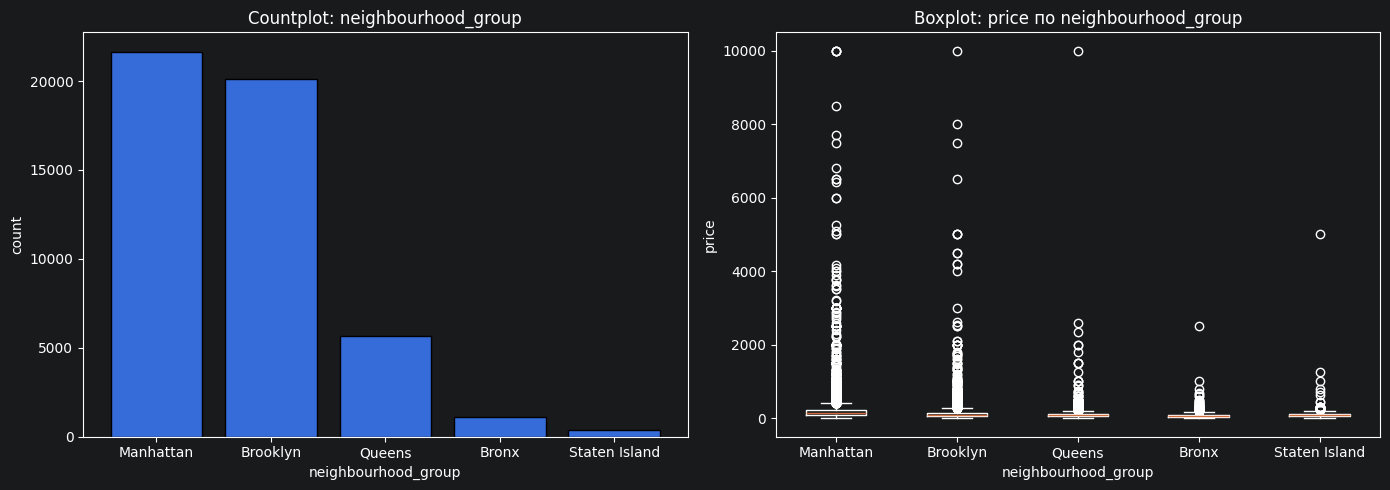

In [19]:
# Анализ neighbourhood_group. countplot и boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
ng_counts = data['neighbourhood_group'].value_counts()
axes[0].bar(ng_counts.index, ng_counts.values, edgecolor='black')
axes[0].set_title('Countplot: neighbourhood_group')
axes[0].set_xlabel('neighbourhood_group')
axes[0].set_ylabel('count')

# Boxplot price по категориям
groups = [data.loc[data['neighbourhood_group'] == g, 'price'].values
          for g in ng_counts.index]
axes[1].boxplot(groups, tick_labels=ng_counts.index, vert=True)
axes[1].set_title('Boxplot: price по neighbourhood_group')
axes[1].set_xlabel('neighbourhood_group')
axes[1].set_ylabel('price')

plt.tight_layout()
plt.show()

In [20]:
# Таблица: среднее и медиана price по neighbourhood_group
ng_stats = data.groupby('neighbourhood_group')['price'].agg(
    count='count',
    mean='mean',
    median='median'
).sort_values('median', ascending=False).round(2)

print('Статистики price по neighbourhood_group:')
print(ng_stats)

Статистики price по neighbourhood_group:
                     count    mean  median
neighbourhood_group                       
Manhattan            21661  196.88   150.0
Brooklyn             20104  124.38    90.0
Queens                5666   99.52    75.0
Staten Island          373  114.81    75.0
Bronx                 1091   87.50    65.0


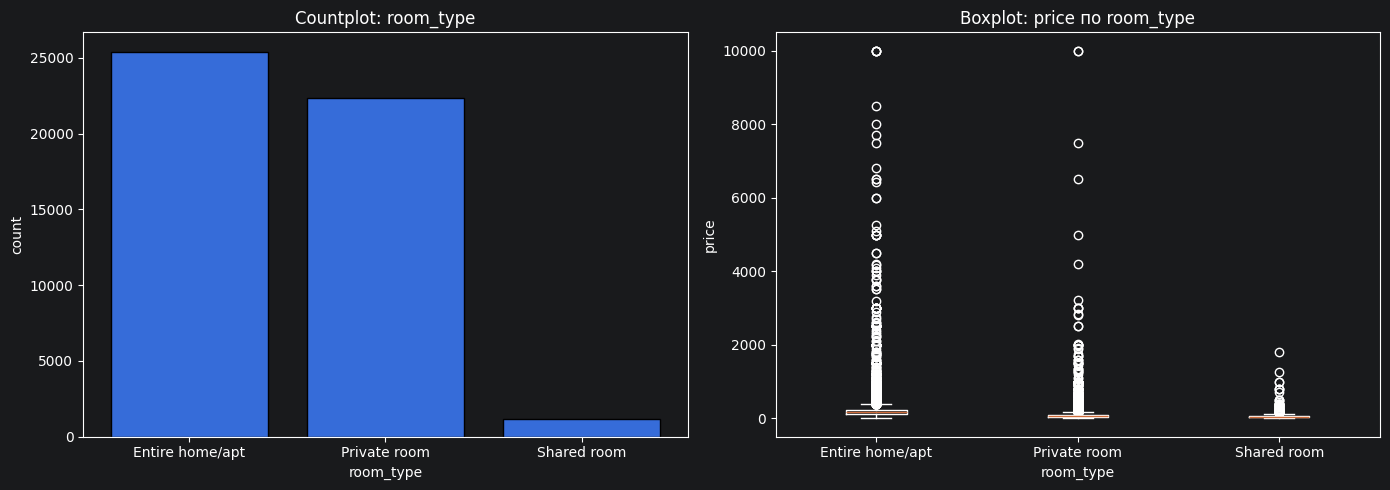

In [21]:
# Анализ room_type. countplot и boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
rt_counts = data['room_type'].value_counts()
axes[0].bar(rt_counts.index, rt_counts.values, edgecolor='black')
axes[0].set_title('Countplot: room_type')
axes[0].set_xlabel('room_type')
axes[0].set_ylabel('count')

# Boxplot price по категориям
groups = [data.loc[data['room_type'] == g, 'price'].values
          for g in rt_counts.index]
axes[1].boxplot(groups, tick_labels=rt_counts.index, vert=True)
axes[1].set_title('Boxplot: price по room_type')
axes[1].set_xlabel('room_type')
axes[1].set_ylabel('price')

plt.tight_layout()
plt.show()

In [22]:
# Таблица: среднее и медиана price по room_type
rt_stats = data.groupby('room_type')['price'].agg(
    count='count',
    mean='mean',
    median='median'
).sort_values('median', ascending=False).round(2)

print('Статистики price по room_type:')
print(rt_stats)

Статистики price по room_type:
                 count    mean  median
room_type                             
Entire home/apt  25409  211.79   160.0
Private room     22326   89.78    70.0
Shared room       1160   70.13    45.0


In [23]:
# Анализ neighbourhood. Агрегированная таблица по районам
neighbourhood_stats = data.groupby('neighbourhood')['price'].agg(
    count='count',
    mean='mean',
    median='median'
).round(2)

print(f'Всего уникальных районов: {len(neighbourhood_stats)}')
print()
print('Top-10 по количеству объектов:')
print(neighbourhood_stats.sort_values('count', ascending=False).head(10))
print()
print('Top-10 по медианной цене (минимум 50 объектов):')
print(neighbourhood_stats[neighbourhood_stats['count'] >= 50]
      .sort_values('median', ascending=False).head(10))

Всего уникальных районов: 221

Top-10 по количеству объектов:
                    count    mean  median
neighbourhood                            
Williamsburg         3920  143.80   105.0
Bedford-Stuyvesant   3714  107.68    80.0
Harlem               2658  118.97    89.0
Bushwick             2465   84.80    65.0
Upper West Side      1971  210.92   150.0
Hell's Kitchen       1958  204.79   168.0
East Village         1853  186.08   150.0
Upper East Side      1798  188.95   149.0
Crown Heights        1564  112.48    85.0
Midtown              1545  282.72   210.0

Top-10 по медианной цене (минимум 50 объектов):
                    count    mean  median
neighbourhood                            
Tribeca               177  490.64   295.0
NoHo                   78  295.72   250.0
Flatiron District      80  341.92   225.0
Midtown              1545  282.72   210.0
West Village          768  267.68   200.0
Financial District    744  225.49   200.0
SoHo                  358  287.10   199.0
Chelsea

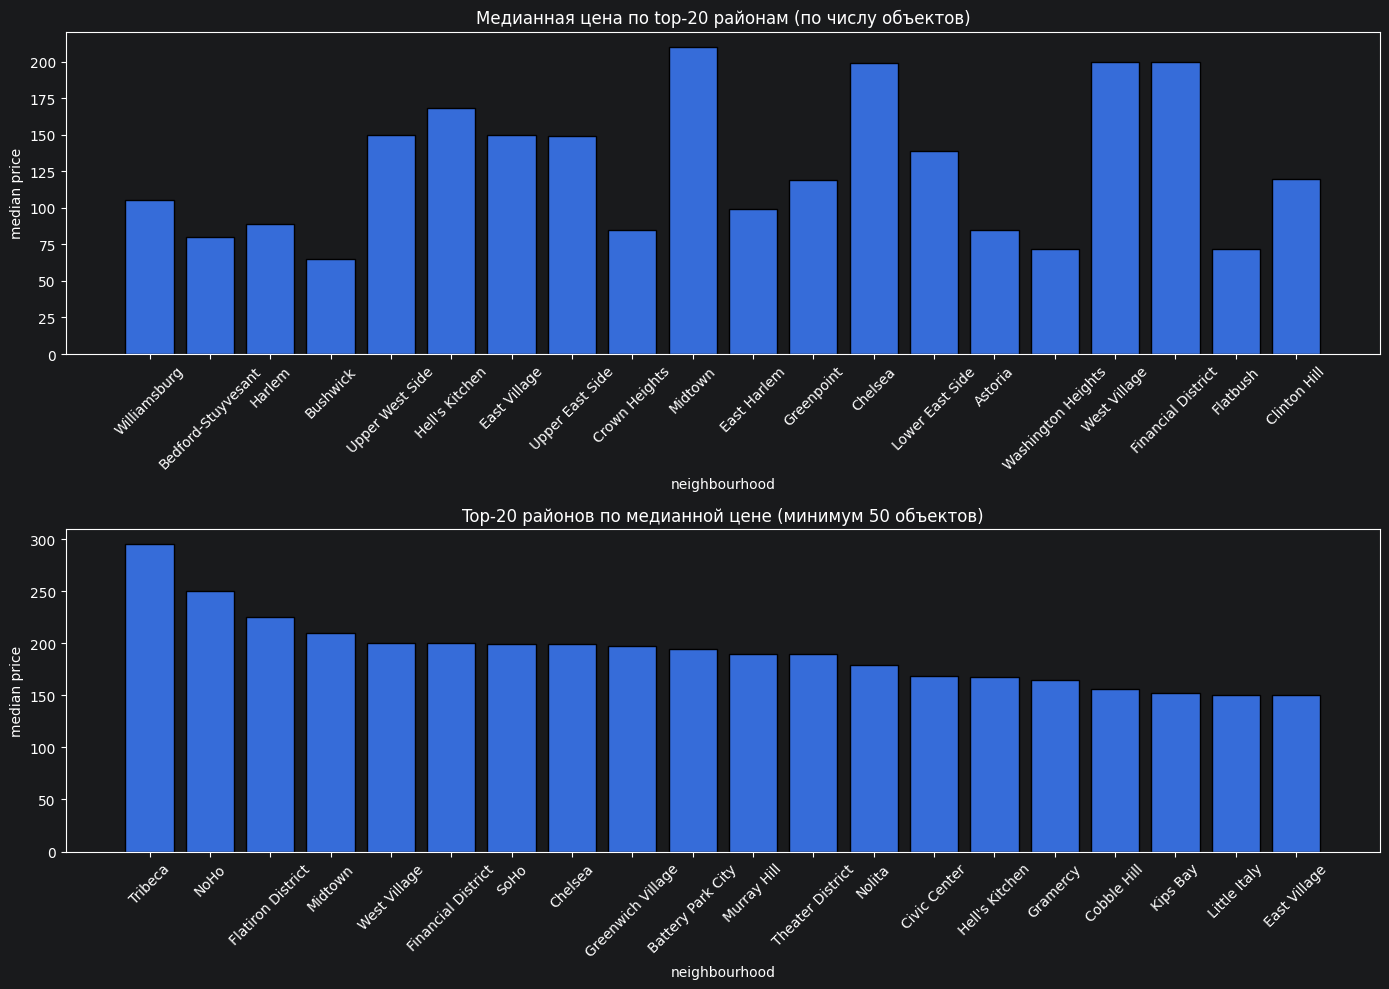

In [24]:
# Визуализация: top-20 районов по числу наблюдений
top20_by_count = neighbourhood_stats.sort_values('count', ascending=False).head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Медианная цена по top-20 районам
axes[0].bar(top20_by_count.index, top20_by_count['median'], edgecolor='black')
axes[0].set_title('Медианная цена по top-20 районам (по числу объектов)')
axes[0].set_xlabel('neighbourhood')
axes[0].set_ylabel('median price')
axes[0].tick_params(axis='x', rotation=45)

# Top-20 районов по медианной цене (≥50 объектов)
top20_by_price = (neighbourhood_stats[neighbourhood_stats['count'] >= 50]
                  .sort_values('median', ascending=False).head(20))
axes[1].bar(top20_by_price.index, top20_by_price['median'], edgecolor='black')
axes[1].set_title('Top-20 районов по медианной цене (минимум 50 объектов)')
axes[1].set_xlabel('neighbourhood')
axes[1].set_ylabel('median price')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Выводы:**
- `room_type` явно связан с ценой: `Entire home/apt` заметно дороже `Private room` и `Shared room`, соответсвенно признак высоко информативен.
- `neighbourhood_group` также связан с ценой. Manhattan в среднем и по медиане дороже остальных районов.
- `neighbourhood` потенциально информативен. Медианная цена существенно варьируется от района к району. Однако, признак имеет 200+ уникальных значений, поэтому требебует кодирования, такого как target encoding или группировка предпочтительнее one-hot encoding.

### 6. Анализ геоданных

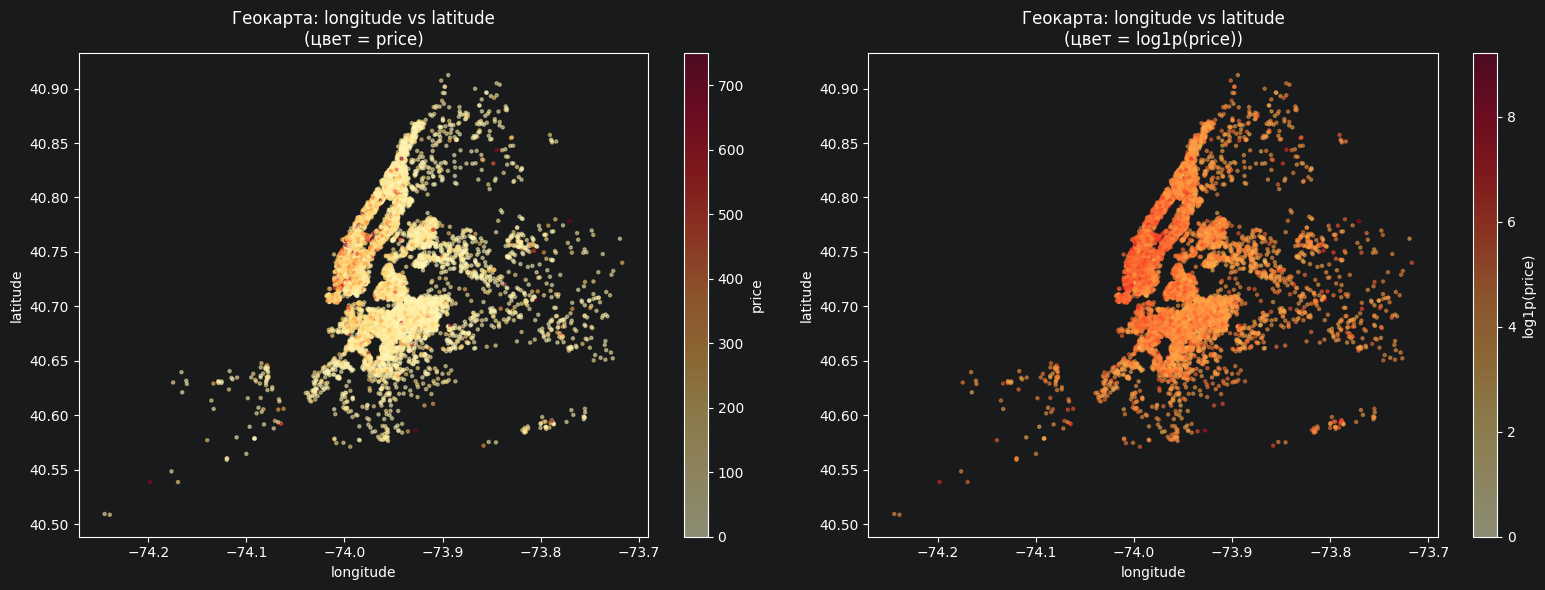

In [25]:
# Scatterplot longitude vs latitude. log1p(price)
# Используем выборку 10 000 точек: полный датасет даёт слишком плотный график
sample = data.sample(n=10_000, random_state=42)
log_price_sample = np.log1p(sample['price'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- price (исходная) ---
sc0 = axes[0].scatter(
    sample['longitude'], sample['latitude'],
    c=sample['price'],
    cmap='YlOrRd',
    alpha=0.5,
    s=5,
    vmax=sample['price'].quantile(0.99)   # обрезаем хвост, чтобы цветовая шкала не схлопывалась
)
plt.colorbar(sc0, ax=axes[0], label='price')
axes[0].set_title('Геокарта: longitude vs latitude\n(цвет = price)')
axes[0].set_xlabel('longitude')
axes[0].set_ylabel('latitude')

# --- log1p(price) ---
sc1 = axes[1].scatter(
    sample['longitude'], sample['latitude'],
    c=log_price_sample,
    cmap='YlOrRd',
    alpha=0.5,
    s=5
)
plt.colorbar(sc1, ax=axes[1], label='log1p(price)')
axes[1].set_title('Геокарта: longitude vs latitude\n(цвет = log1p(price))')
axes[1].set_xlabel('longitude')
axes[1].set_ylabel('latitude')

plt.tight_layout()
plt.show()

**Выводы:**
- На карте видна чёткая структура: зоны с более высокими ценами располагаются в центральной части (Manhattan) и на отдельных участках Brooklyn.
- График с `log1p(price)` читается лучше.
- Координаты `latitude` и `longitude` несут полезную информацию о цене. близость центру влияет на стоимость.
- Имеет смысл создать географические признаки, например, расстояние до центра Манхэттена или кластеризацию по координатам.

### 7. Дополнительные визуализации. Pair plots

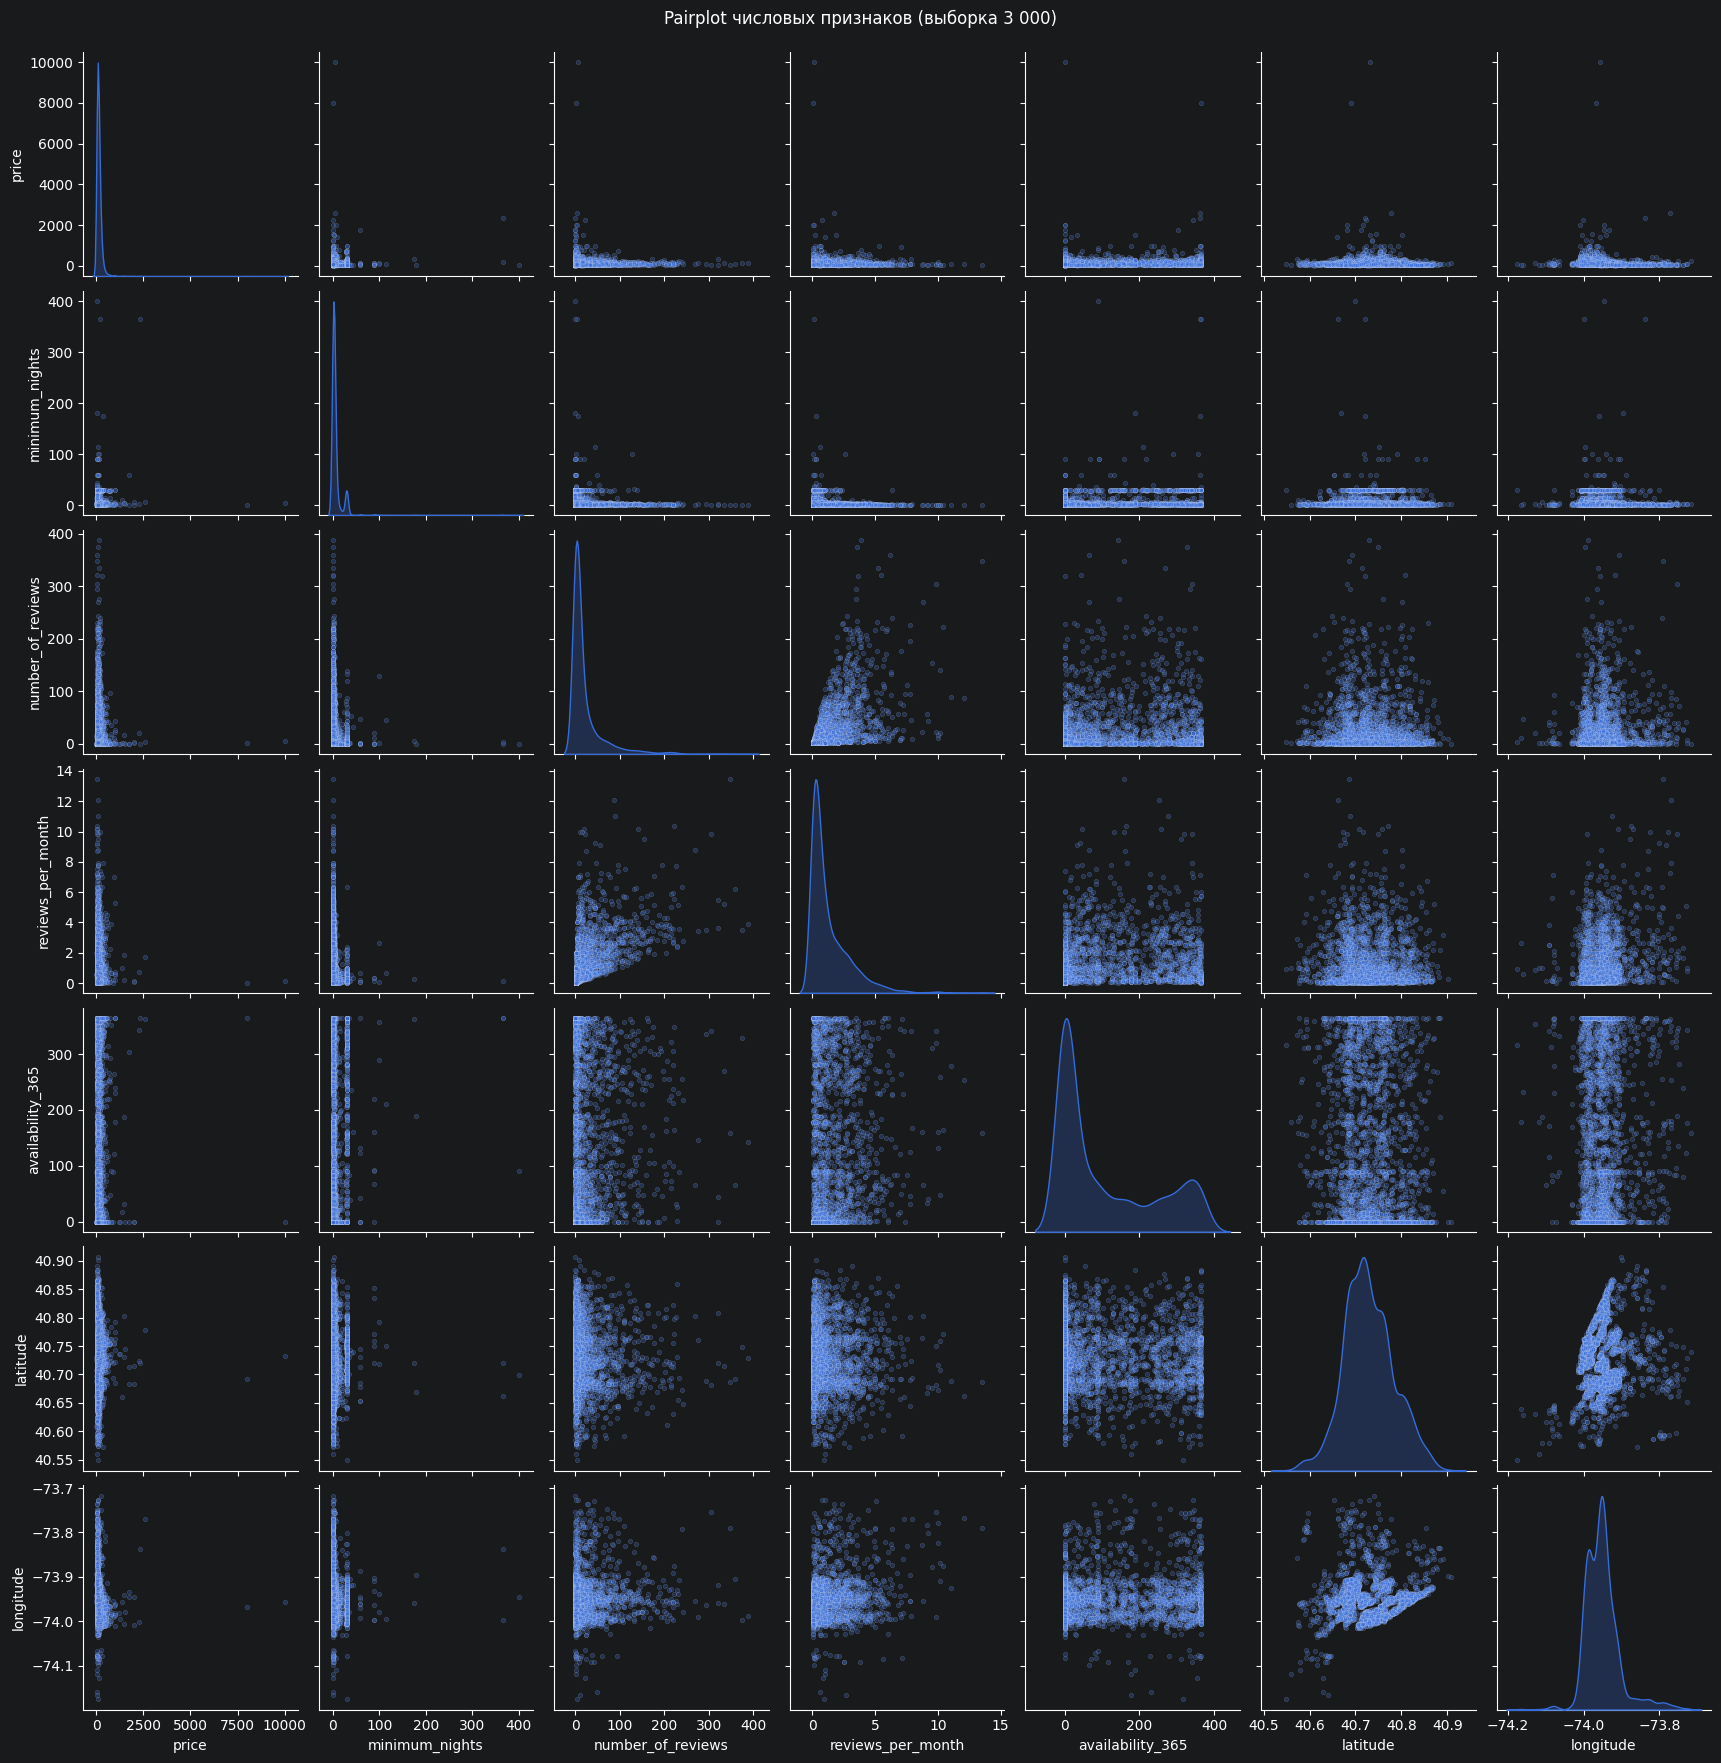

In [26]:
# Pairplot по ограниченному набору признаков
# Используем выборку 3 000 точек. Полный датасет делает pairplot очень тяжёлым
pairplot_cols = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'latitude',
    'longitude',
]

sample_pp = data[pairplot_cols].sample(n=3_000, random_state=42)

sns.pairplot(sample_pp, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot числовых признаков (выборка 3 000)', y=1.01)
plt.show()

**Выводы:**
- `price` имеет сильный правый хвост. scatter-столбцы с `price` визуально сжаты; при необходимости стоит перейти к `log1p(price)`.
- `number_of_reviews` и `reviews_per_month` ожидаемо коррелируют между собой.
- Явной сильной линейной связи ни одного числового признака с `price` не наблюдается, что согласуется с результатами heatmap из раздела 4.

## 8. Итог EDA
После всех графиков можно зафиксировать:
- целевая переменная сильно скошена;
- есть выбросы по цене;
- категориальные признаки связаны с ценой;
- география важна;
- слабая линейная корреляция не является основанием для удаления признака.

## Часть 2. Preprocessing & Feature Engineering

### 1. Разделение на признаки и целевую переменную


In [27]:
X = data.drop(columns='price')
y = data['price']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print()
print('Признаки в X:')
print(X.columns.tolist())

X shape: (48895, 10)
y shape: (48895,)

Признаки в X:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


### 2. Train/test split

Разбиение выполняется **до** любых преобразований, требующих `fit` по данным (заполнение пропусков, encoding, scaling и т.д.), чтобы исключить утечку информации из test в train.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (34226, 10)  |  X_test: (14669, 10)
y_train: (34226,)  |  y_test: (14669,)


### 3. Набор признаков для baseline-эксперимента

Числовые: `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, `availability_365`, `latitude`, `longitude`.

Категориальные: `neighbourhood_group`, `room_type`.

`neighbourhood` (200+ категорий) в baseline не включаем, будет проверен отдельно.

In [29]:
num_features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'latitude',
    'longitude',
]

cat_features = [
    'neighbourhood_group',
    'room_type',
]

baseline_features = num_features + cat_features

print(f'Числовых признаков: {len(num_features)}')
print(f'Категориальных признаков: {len(cat_features)}')
print(f'Всего в baseline: {len(baseline_features)}')
print()
print('Исключён из baseline: neighbourhood '
      f'({X_train["neighbourhood"].nunique()} уникальных значений в train)')

Числовых признаков: 7
Категориальных признаков: 2
Всего в baseline: 9

Исключён из baseline: neighbourhood (217 уникальных значений в train)


## 4. Работа с выбросами

Порог по `price` вычисляется внутри каждого сочетания (`neighbourhood_group`, `neighbourhood`) на train по правилу 1.5×IQR. Строки за пределами порога удаляются только из train. Test не участвует в вычислении порога и не фильтруется.

In [35]:
# Вычисляем границы IQR по (neighbourhood_group, neighbourhood) на train
group_cols = ['neighbourhood_group', 'neighbourhood']

train_with_price = X_train[group_cols].copy()
train_with_price['price'] = y_train

bounds = train_with_price.groupby(group_cols)['price'].agg(
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
)
bounds['iqr'] = bounds['q3'] - bounds['q1']
bounds['lower'] = bounds['q1'] - 1.5 * bounds['iqr']
bounds['upper'] = bounds['q3'] + 1.5 * bounds['iqr']

print('Пример границ (первые 10 групп):')
bounds.head(10)

Пример границ (первые 10 групп):


q1      q3    iqr   lower    upper
neighbourhood_group neighbourhood                                           
Bronx               Allerton           39.75  101.00  61.25 -52.125  192.875
                    Baychester         75.00   85.00  10.00  60.000  100.000
                    Belmont            29.00   96.25  67.25 -71.875  197.125
                    Bronxdale          41.00   71.50  30.50  -4.750  117.250
                    Castle Hill        39.00   80.00  41.00 -22.500  141.500
                    City Island        82.00  117.50  35.50  28.750  170.750
                    Claremont Village  51.25  107.50  56.25 -33.125  191.875
                    Clason Point       63.75  110.00  46.25  -5.625  179.375
                    Co-op City         76.25   78.75   2.50  72.500   82.500
                    Concourse          45.00  102.75  57.75 -41.625  189.375

In [36]:
# Применяем фильтр к train
train_merged = train_with_price.merge(bounds, left_on=group_cols, right_index=True)
mask = (train_merged['price'] >= train_merged['lower']) & (train_merged['price'] <= train_merged['upper'])

n_before = len(X_train)
X_train = X_train.loc[mask.values]
y_train = y_train.loc[mask.values]
n_after = len(X_train)

print(f'Train до фильтрации:  {n_before}')
print(f'Train после фильтрации: {n_after}')
print(f'Удалено выбросов: {n_before - n_after} ({(n_before - n_after) / n_before * 100:.1f}%)')
print()
print(f'Test не изменён: {len(X_test)}')

Train до фильтрации:  34226
Train после фильтрации: 32040
Удалено выбросов: 2186 (6.4%)

Test не изменён: 14669


### 5. Обработка пропусков

- Числовые признаки: `SimpleImputer(strategy='median')`
- Категориальные признаки: `SimpleImputer(strategy='most_frequent')`

Imputer обучается (`fit`) только на train, на test только `transform`.

In [37]:
# Пропуски до обработки
print('Пропуски в X_train (baseline-признаки):')
print(X_train[baseline_features].isnull().sum())
print()
print('Пропуски в X_test (baseline-признаки):')
print(X_test[baseline_features].isnull().sum())

Пропуски в X_train (baseline-признаки):
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 6437
calculated_host_listings_count       0
availability_365                     0
latitude                             0
longitude                            0
neighbourhood_group                  0
room_type                            0
dtype: int64

Пропуски в X_test (baseline-признаки):
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 2994
calculated_host_listings_count       0
availability_365                     0
latitude                             0
longitude                            0
neighbourhood_group                  0
room_type                            0
dtype: int64


### 6. Кодирование категориальных признаков

`OneHotEncoder(handle_unknown='ignore')` для `neighbourhood_group` и `room_type`. Encoder обучается только на train.

### 7. Масштабирование числовых признаков

`RobustScaler` устойчив к выбросам (использует медиану и IQR). Scaler обучается только на train.

### 8. Единый baseline preprocessing через ColumnTransformer

Объединяем шаги 5–7:
- **num_pipeline**: `SimpleImputer(median)` -> `RobustScaler`
- **cat_pipeline**: `SimpleImputer(most_frequent)` -> `OneHotEncoder(handle_unknown='ignore')`

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder

baseline_num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

baseline_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('num', baseline_num_pipeline, num_features),
        ('cat', baseline_cat_pipeline, cat_features),
    ],
)

# fit на train, transform на train и test
X_train_baseline = baseline_preprocessor.fit_transform(X_train[baseline_features])
X_test_baseline = baseline_preprocessor.transform(X_test[baseline_features])

# Имена столбцов
ohe_names = (baseline_preprocessor
             .named_transformers_['cat']
             .named_steps['encoder']
             .get_feature_names_out(cat_features)
             .tolist())
baseline_col_names = num_features + ohe_names

X_train_baseline = pd.DataFrame(X_train_baseline, columns=baseline_col_names, index=X_train.index)
X_test_baseline = pd.DataFrame(X_test_baseline, columns=baseline_col_names, index=X_test.index)

print(f'X_train_baseline: {X_train_baseline.shape}')
print(f'X_test_baseline:  {X_test_baseline.shape}')
print()
print('Признаки:', baseline_col_names)
print()
X_train_baseline.head()

X_train_baseline: (32040, 15)
X_test_baseline:  (14669, 15)

Признаки: ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']



,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,longitude,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
21681,-0.25,2.608696,1.210526,0.0,1.037037,-0.422407,4.511269,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
26482,-0.25,0.826087,0.323308,0.0,-0.125000,-0.853027,-0.835158,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
20859,0.50,-0.130435,-0.488722,0.0,-0.180556,0.264860,-0.400944,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
45464,-0.50,-0.043478,1.609023,2.0,-0.180556,-0.494953,0.208414,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
22583,0.00,0.043478,-0.360902,0.0,-0.180556,0.509325,-0.215068,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### 9. Подготовка датасетов для экспериментов

Каждый эксперимент меняет ровно один фактор относительно baseline:
- **Эксперимент 1** — только target: `log1p(price)`
- **Эксперимент 2** — только признаки: добавляем расстояние до центра Манхэттена
- **Эксперимент 3** — только кодирование: добавляем target encoding для `neighbourhood`

#### Эксперимент 1: логарифмирование целевой переменной

Признаки и preprocessing те же, что в baseline. Меняется только target: `log1p(y_train)`. Метрики будут считаться в исходной шкале `price` (через `expm1`).

In [39]:
import numpy as np

# Эксперимент 1: данные — baseline, target — log1p
X_train_exp1 = X_train_baseline.copy()
X_test_exp1 = X_test_baseline.copy()
y_train_exp1 = np.log1p(y_train)

print(f'Эксперимент 1: X_train={X_train_exp1.shape}, X_test={X_test_exp1.shape}')
print(f'y_train_exp1: min={y_train_exp1.min():.2f}, max={y_train_exp1.max():.2f}, median={y_train_exp1.median():.2f}')

Эксперимент 1: X_train=(32040, 15), X_test=(14669, 15)
y_train_exp1: min=0.00, max=7.18, median=4.62


#### Эксперимент 2: географические признаки

Добавляем расстояние до центра Манхэттена (Times Square: 40.7588, −73.9851, https://www.latlong.net/place/times-square-nyc-usa-7560.html). Расстояние вычисляется по евклидовой метрике в координатах. Признак добавляется к baseline-набору и проходит тот же preprocessing

In [40]:
# Фиксированная точка: Times Square, Manhattan
CENTER_LAT = 40.7588
CENTER_LON = -73.9851

# Расстояние до центра (евклидово в координатах)
X_train['dist_to_center'] = np.sqrt(
    (X_train['latitude'] - CENTER_LAT) ** 2 +
    (X_train['longitude'] - CENTER_LON) ** 2
)
X_test['dist_to_center'] = np.sqrt(
    (X_test['latitude'] - CENTER_LAT) ** 2 +
    (X_test['longitude'] - CENTER_LON) ** 2
)

# Preprocessing для эксперимента 2: baseline + dist_to_center
exp2_num_features = num_features + ['dist_to_center']
exp2_features = exp2_num_features + cat_features

exp2_num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

exp2_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

exp2_preprocessor = ColumnTransformer(
    transformers=[
        ('num', exp2_num_pipeline, exp2_num_features),
        ('cat', exp2_cat_pipeline, cat_features),
    ],
)

X_train_exp2 = exp2_preprocessor.fit_transform(X_train[exp2_features])
X_test_exp2 = exp2_preprocessor.transform(X_test[exp2_features])

exp2_ohe_names = (exp2_preprocessor
                  .named_transformers_['cat']
                  .named_steps['encoder']
                  .get_feature_names_out(cat_features)
                  .tolist())
exp2_col_names = exp2_num_features + exp2_ohe_names

X_train_exp2 = pd.DataFrame(X_train_exp2, columns=exp2_col_names, index=X_train.index)
X_test_exp2 = pd.DataFrame(X_test_exp2, columns=exp2_col_names, index=X_test.index)

print(f'Эксперимент 2: X_train={X_train_exp2.shape}, X_test={X_test_exp2.shape}')
print(f'Новый признак: dist_to_center')
print()
X_train_exp2[['latitude', 'longitude', 'dist_to_center']].head()

Эксперимент 2: X_train=(32040, 16), X_test=(14669, 16)
Новый признак: dist_to_center



,latitude,longitude,dist_to_center
21681,-0.422407,4.511269,3.378533
26482,-0.853027,-0.835158,0.617663
20859,0.264860,-0.400944,-0.833878
45464,-0.494953,0.208414,0.311362
22583,0.509325,-0.215068,-0.838458
